# Data Analysis and Machine Learning with Python
In this project, I work with data from the Global Preferences Survey, a globally representative dataset on risk and time preferences, positive and negative reciprocity, altruism, and trust. <br>
Further information can be found on the website (https://gps.iza.org/) and in the paper "Global Evidence on Economic Preferences" by Falk, Becker, Dohmen, Enke, Huffman, and Sunde, published in *The Quarterly Journal of Economics* 133(4): 1645–1692, 2018 (https://doi.org/10.1093/qje/qjy013).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import folium
from folium.plugins import MarkerCluster
import statsmodels.formula.api as smf
import pycountry
import pycountry_convert as pc  

## Problem 1 - Data Handling
The basis of this will be the dataset containing information on and preferences of individuals (`individual_new.csv`):
- *country*: Country name
- *isocode*: Three-letter country codes ISO 3166-1 alpha-3
- *ison*: Three-digit country codes ISO 3166-1 numeric
- *region*: Subnational region of interview
- *language*: Interview language
- *date*: Interview date
- *id*: Respondent ID
- *wgt*: Sampling weight of the observation
- *patience*: Level of patience
- *risktaking*: Willingness to take risks
- *posrecip*: Positive reciprocity
- *negrecip*: Negative reciprocity
- *altruism*: Level of altruism
- *trust*: Level of trust
- *subj_math_skills*: Subjective math skills from 0 to 10
- *female*: Indicator for female
- *age*: Age

Note that the variables *patience*, *risktaking*, *posrecip*, *negrecip*, *altruism* and *trust* are normalized to mean 0 and standard deviation 1.

In [2]:
df = pd.read_csv("individual_new.csv", sep=",")
df

,country,isocode,ison,region,language,date,id,wgt,patience,risktaking,posrecip,negrecip,altruism,trust,subj_math_skills,female,age
0,Afghanistan,AFG,4,Kabul,Dari,20-Apr-12,7.110000e+12,0.275232,-0.038009,0.384144,0.959891,0.399410,0.003642,0.950434,9.0,0,30
1,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,0.647113,0.142709,1.020203,0.594384,1.592820,1.500414,0.950434,10.0,0,18
2,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,0.275232,0.865583,0.768879,1.325398,2.333531,1.552305,1.679754,10.0,0,22
3,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,0.666598,-0.038009,0.796841,0.228877,1.183409,-0.762638,1.679754,7.0,0,56
4,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,1.476726,1.046301,1.020203,0.959891,1.453366,0.055532,0.585774,5.0,0,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80332,Zimbabwe,ZWE,716,Masvingo,Shona,28-Feb-12,7.110000e+12,0.520770,-0.293085,0.135853,1.027741,-1.586460,-0.152030,0.221113,2.0,1,56
80333,Zimbabwe,ZWE,716,Masvingo,English,2-Mar-12,7.110000e+12,0.853304,-0.420622,1.640765,0.730084,-0.924503,0.809108,-0.508207,8.0,1,27
80334,Zimbabwe,ZWE,716,Masvingo,English,2-Mar-12,7.110000e+12,0.496437,-0.165547,0.564047,1.325398,-1.046319,1.023022,-0.143547,7.0,0,36
80335,Zimbabwe,ZWE,716,Masvingo,English,2-Mar-12,7.110000e+12,0.496437,-0.420622,0.387177,0.432427,-1.438318,-0.459347,-1.602187,4.0,0,36


#### a)
Explore the dataset:
- Check for missing values
- Check for the correct datatype of the variables

In [3]:
print(df.dtypes)

country              object
isocode              object
ison                  int64
region               object
language             object
date                 object
id                  float64
wgt                 float64
patience            float64
risktaking          float64
posrecip            float64
negrecip            float64
altruism            float64
trust               float64
subj_math_skills    float64
female                int64
age                  object
dtype: object


The 'age' column is object type but should be numeric (int or float).
We convert it using pd.to_numeric(), and invalid entries become NaN. 
 convert non-numeric to NaN

In [4]:
df['age'] = pd.to_numeric(df['age'], errors='coerce') 

In [5]:
missing_count = df.isna().sum()
missing_ratio = df.isnull().mean() * 100 
missing_summary = pd.DataFrame({ 'Missing Count': missing_count, 'Missing Ratio (%)': missing_ratio.round(2)})
print(missing_summary)

                  Missing Count  Missing Ratio (%)
country                       0               0.00
isocode                       0               0.00
ison                          0               0.00
region                     1008               1.25
language                      0               0.00
date                        515               0.64
id                            0               0.00
wgt                           0               0.00
patience                    607               0.76
risktaking                  634               0.79
posrecip                    148               0.18
negrecip                   1801               2.24
altruism                    434               0.54
trust                      1563               1.95
subj_math_skills           1126               1.40
female                        0               0.00
age                         308               0.38


region: Since only 1.25% is missing and it’s categorical, we simply fill with "Unknown".
date: Only 0.6% missing and not essential unless you’re doing time-series analysis — we drop it for simplicity.
Preference columns (patience, trust, etc.):
Missingness is <2.5% for all.
We fill using the median, which is robust to outliers and retains most of the sample.
 subj_math_skills & age: Slightly more missing, but imputation via median is reasonable, especially since age is important for regression or stratified analysis.

In [6]:
df = df.copy()
df['region'] = df['region'].fillna('Unknown')
df = df.dropna(subset=['date'])
numerical_cols = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust', 'subj_math_skills', 'age']
for col in numerical_cols:
    if col in df.columns:
        median_value = df[col].median()
        df.loc[:, col] = df[col].fillna(median_value)
    else:
        print(f"'{col}' no exist")
print("Missing after imputation:")
print(df.isna().sum())

Missing after imputation:
country             0
isocode             0
ison                0
region              0
language            0
date                0
id                  0
wgt                 0
patience            0
risktaking          0
posrecip            0
negrecip            0
altruism            0
trust               0
subj_math_skills    0
female              0
age                 0
dtype: int64


In [7]:
df

,country,isocode,ison,region,language,date,id,wgt,patience,risktaking,posrecip,negrecip,altruism,trust,subj_math_skills,female,age
0,Afghanistan,AFG,4,Kabul,Dari,20-Apr-12,7.110000e+12,0.275232,-0.038009,0.384144,0.959891,0.399410,0.003642,0.950434,9.0,0,30.0
1,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,0.647113,0.142709,1.020203,0.594384,1.592820,1.500414,0.950434,10.0,0,18.0
2,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,0.275232,0.865583,0.768879,1.325398,2.333531,1.552305,1.679754,10.0,0,22.0
3,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,0.666598,-0.038009,0.796841,0.228877,1.183409,-0.762638,1.679754,7.0,0,56.0
4,Afghanistan,AFG,4,Kabul,Dari,21-Apr-12,7.110000e+12,1.476726,1.046301,1.020203,0.959891,1.453366,0.055532,0.585774,5.0,0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80332,Zimbabwe,ZWE,716,Masvingo,Shona,28-Feb-12,7.110000e+12,0.520770,-0.293085,0.135853,1.027741,-1.586460,-0.152030,0.221113,2.0,1,56.0
80333,Zimbabwe,ZWE,716,Masvingo,English,2-Mar-12,7.110000e+12,0.853304,-0.420622,1.640765,0.730084,-0.924503,0.809108,-0.508207,8.0,1,27.0
80334,Zimbabwe,ZWE,716,Masvingo,English,2-Mar-12,7.110000e+12,0.496437,-0.165547,0.564047,1.325398,-1.046319,1.023022,-0.143547,7.0,0,36.0
80335,Zimbabwe,ZWE,716,Masvingo,English,2-Mar-12,7.110000e+12,0.496437,-0.420622,0.387177,0.432427,-1.438318,-0.459347,-1.602187,4.0,0,36.0


#### b)
Identify potential correlations between different variables. <br>
Are there regional differences in certain preferences?

Although the preferences are normalized to mean zero and unit variance, individual heterogeneity is evident. The interquartile ranges suggest meaningful variation, and some variables—like positive reciprocity and patience—exhibit long tails. Median values are slightly negative for patience, trust, and risk-taking, indicating asymmetry in these preferences at the individual level.

In [8]:
prefs = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust']
summary_stats = df[prefs].describe()
print(summary_stats)

           patience    risktaking      posrecip      negrecip      altruism  \
count  79822.000000  79822.000000  79822.000000  79822.000000  79822.000000   
mean      -0.000452     -0.000429     -0.000864      0.002163     -0.002663   
std        0.997587      0.996649      0.998537      0.987379      0.996722   
min       -1.313386     -1.874741     -3.844215     -1.586460     -2.610568   
25%       -0.675698     -0.618120     -0.664094     -0.775909     -0.630436   
50%       -0.293085     -0.047083      0.228877      0.008089      0.034776   
75%        0.424615      0.650966      0.662234      0.686781      0.696112   
max        2.763126      2.466159      1.325398      2.333531      2.330662   

              trust  
count  79822.000000  
mean      -0.001140  
std        0.989876  
min       -1.966848  
25%       -0.508207  
50%       -0.143547  
75%        0.585774  
max        1.679754  


“Are economic preferences correlated with each other at the individual level?”
Individual-Level Correlation (Heatmap 1)

Observations:
（1）Most correlations are very weak (< 0.2).
（2）Patience and risk taking: moderate correlation (r ≈ 0.20)
（3）Altruism and positive reciprocity: moderate correlation (r ≈ 0.37)
（4）Most other pairs: weak or no correlation

Interpretation:
（1）At the individual level, preferences are largely independent, supporting the idea that people have diverse behavioral profiles.
（2）This reflects the original paper’s point: “most preference dimensions are only weakly correlated at the individual level.”    

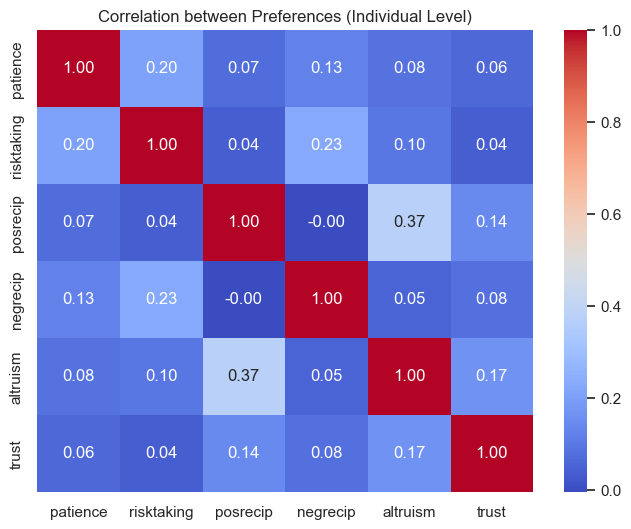

In [9]:
prefs = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust']
corr_matrix = df[prefs].corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Preferences (Individual Level)")
plt.show()

I model each preference as a function of:
preference ~ female + subj_math_skills + age + I(age ** 2)

This model results confirm that economic preferences vary systematically with gender, cognitive ability, and age, as follows:
（1）Gender Effects (variable = female)Women are significantly:
Less risk-taking (coef = -0.186, p < 1e-150),
More altruistic (+0.093), more trusting (+0.066),
more positively reciprocal (+0.069),
Less negatively reciprocal (-0.135), slightly less patient (-0.048), but the effect is small
(2)Cognitive Ability (variable = subj_math_skills) are positively and significantly associated with all preferences:
More patient, more risk-tolerant, more trusting, more altruistic, more reciprocal
Effects are very consistent, e.g. coef ≈ 0.04–0.06 with p < 1e-200
(3)Age and Nonlinear Age Effects
Patience, positive reciprocity, and trust: Increase with age (+) but flatten or decline slightly due to negative quadratic term
Risk-taking: Decreases with age (-0.003) and accelerates downward (neg. age²)
Altruism & negative reciprocity: Age effects are not significant (p > 0.3

My regression analysis confirms that individual economic preferences vary systematically by gender, cognitive ability, and age. Women are more prosocial and less risk-tolerant than men. Higher cognitive skills are uniformly associated with greater patience, risk-taking, and social preferences. Age effects follow nonlinear patterns: trust and patience increase with age but exhibit diminishing returns, while risk-taking declines steadily. These patterns are highly significant and align with existing findings in the literature.

In [10]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['subj_math_skills'] = pd.to_numeric(df['subj_math_skills'], errors='coerce')
prefs = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust']
summary_list = []
for pref in prefs:
    formula = f"{pref} ~ female + subj_math_skills + age + I(age ** 2)"
    model = smf.ols(formula, data=df).fit()
    for var in ['female', 'subj_math_skills', 'age', 'I(age ** 2)']:
        coef = model.params[var]
        pval = model.pvalues[var]
        summary_list.append({'preference': pref,'variable': var,'coef': round(coef, 3),'p-value': f"{pval:.2e}" if pval < 0.01 else round(pval, 3) })
summary_df = pd.DataFrame(summary_list)
summary_pivot = summary_df.pivot(index='preference', columns='variable', values='coef')
print(summary_df)

    preference          variable   coef    p-value
0     patience            female -0.048   1.68e-11
1     patience  subj_math_skills  0.045  1.84e-278
2     patience               age  0.015   2.13e-47
3     patience       I(age ** 2) -0.000   3.01e-56
4   risktaking            female -0.186  3.86e-163
5   risktaking  subj_math_skills  0.048   0.00e+00
6   risktaking               age -0.003   8.86e-03
7   risktaking       I(age ** 2) -0.000   4.29e-28
8     posrecip            female  0.069   4.37e-22
9     posrecip  subj_math_skills  0.042  4.58e-240
10    posrecip               age  0.014   1.03e-41
11    posrecip       I(age ** 2) -0.000   1.68e-37
12    negrecip            female -0.135   8.39e-84
13    negrecip  subj_math_skills  0.042  5.31e-250
14    negrecip               age  0.001      0.401
15    negrecip       I(age ** 2) -0.000   1.76e-14
16    altruism            female  0.093   1.06e-39
17    altruism  subj_math_skills  0.043  1.08e-256
18    altruism               ag

Country-Level Correlation (Heatmap 2)

Observations:
（1）Positive reciprocity and altruism: very high correlation (r = 0.70)
（2）Positive reciprocity and trust: moderate correlation (r = 0.34)
（3）Patience and trust: mild correlation (r = 0.22)
（4）Patience and negrecip: positive correlation (r = 0.26)

Interpretation:
（1）At the country level, preferences are more clustered: for example, countries with high positive reciprocity also show higher altruism and trust.
（2）Suggests national cultures may promote coherent “preference bundles.”

This confirms the paper’s claim:
“Preferences are not independent across countries but form meaningful clusters.” 

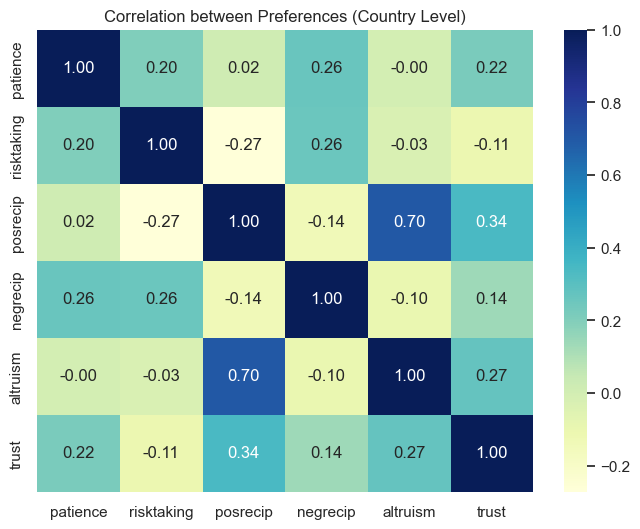

In [11]:
country_means = df.groupby('country')[prefs].mean()
country_corr = country_means.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(country_corr, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation between Preferences (Country Level)")
plt.show()

To investigate the structure of prosocial preferences across countries, we computed the Pearson correlation coefficient between country-level averages of altruism and positive reciprocity, resulting in r = 0.70 with a p-value ≈ 1.38 × 10⁻¹².

This indicates a strong and statistically significant positive relationship between the two prosocial preferences at the national level.

In other words, countries where people are more altruistic also tend to have stronger norms of positive reciprocity.

This supports the hypothesis that prosocial preferences tend to cluster culturally, forming coherent preference bundles — a finding consistent with the conclusions in Falk et al. (2018).  


In [12]:
from scipy.stats import pearsonr
country_means = df.groupby('country')[['altruism', 'posrecip']].mean()
r, p = pearsonr(country_means['altruism'], country_means['posrecip'])
print(f"Country-level correlation: r = {r:.2f}, p = {p:.15f}")

Country-level correlation: r = 0.70, p = 0.000000000001382


Results show that most correlations are weak (|r| < 0.2), confirming that behavioral preferences are largely distinct constructs. The strongest relationship is between altruism and positive reciprocity (r = 0.37).

At the country level, preferences exhibit stronger and more coherent clustering. The correlation between national averages of altruism and positive reciprocity reaches r = 0.70 (p < 1e-12), suggesting shared cultural norms shape prosocial behavior. This supports Falk et al.’s conclusion that preferences are weakly correlated across individuals but form meaningful clusters across countries.

## Problem 2 - Data Visualization

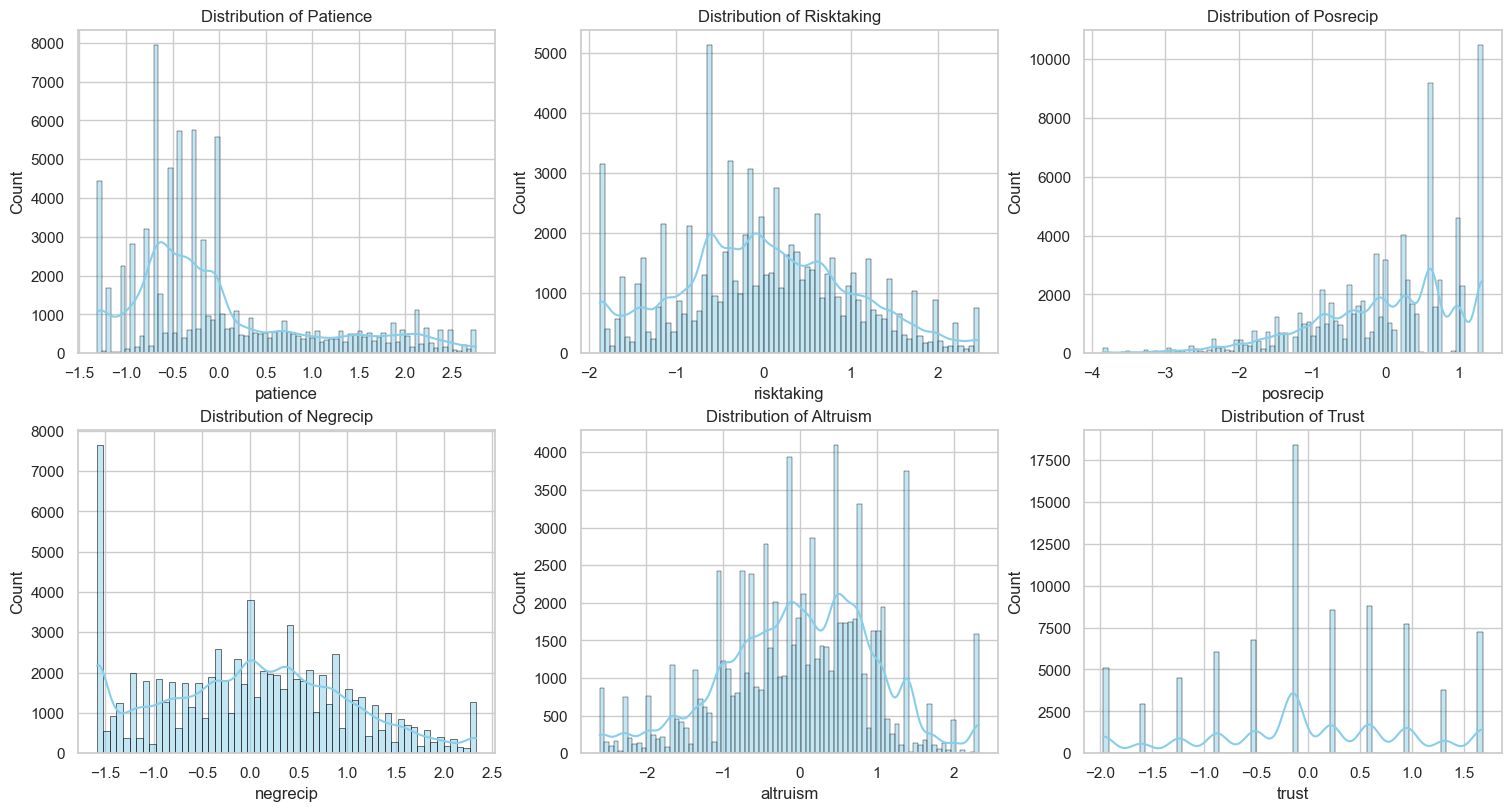

In [13]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2,3,figsize=(15,8), constrained_layout=True)
axes = axes.flatten()
for i, pref in enumerate(prefs):
    sns.histplot(df[pref], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f"Distribution of {pref.capitalize()}")
plt.show()

These histograms show the distribution of global economic preferences. Most preferences are not normally distributed, and there exists strong clustering and peaks at specific values (notably an unusual peak in the most negative values for negative reciprocity, implying a strong unwillingness). The spikes can be explained by the questionnaire design, which required respondents to choose from a limited set of discrete answers.

Follow this up by breaking these distributions down by country or gender, we want to see if these patterns are consistent across groups or driven by certain populations. 

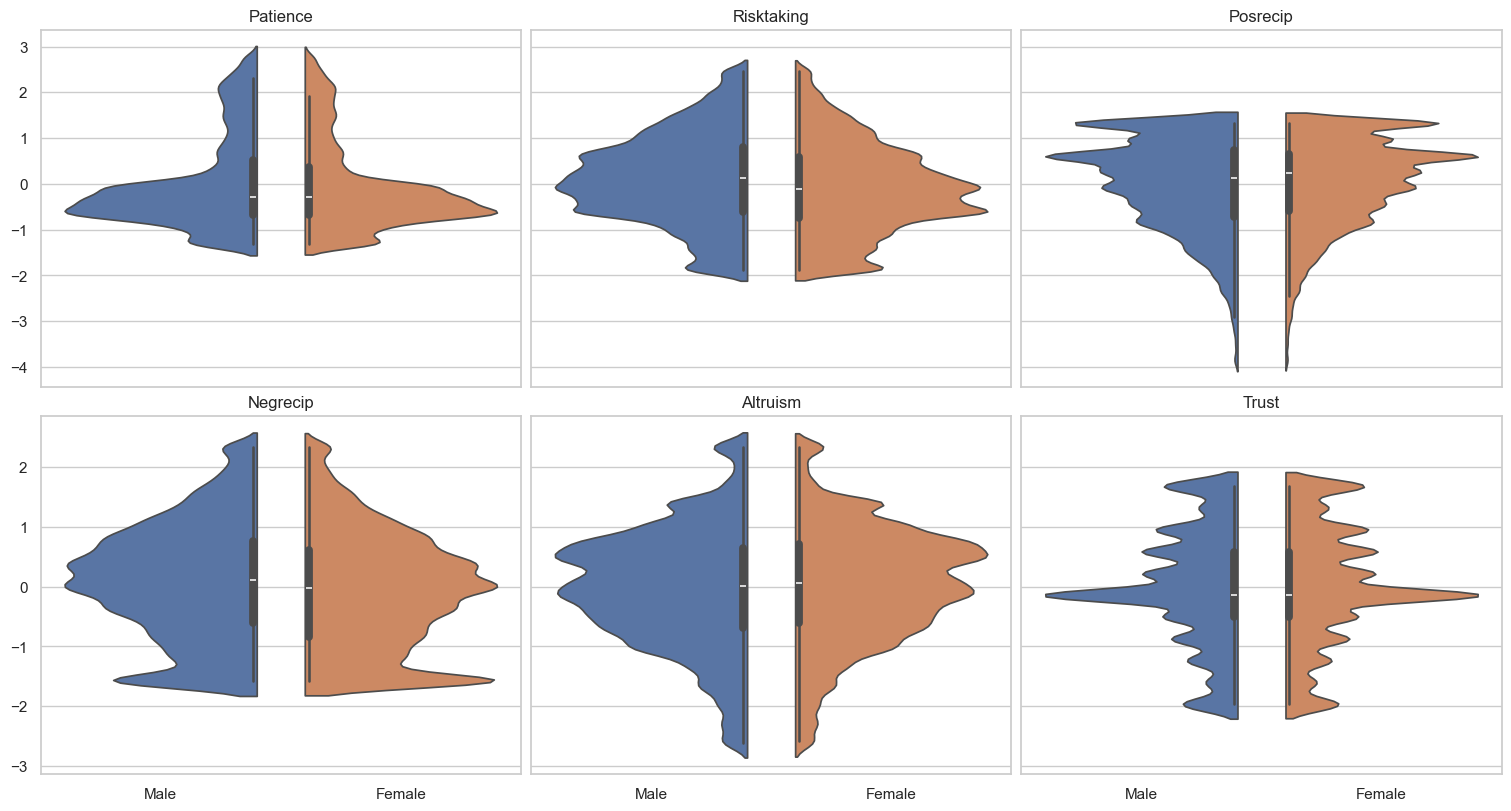

In [14]:
df_gender = df.copy()
df_gender['female'] = df_gender['female'].map({0: 'Male', 1: 'Female'})

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, sharex='col', sharey='row', figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

for i, pref in enumerate(prefs):
    sns.violinplot(data=df_gender, x="female", y=pref, ax=axes[i], hue="female", split=True)
    axes[i].set_title(pref.capitalize())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
plt.show()

In line with the above results, the violin plots indicate higher prosocial and risk aversion preferences in females.

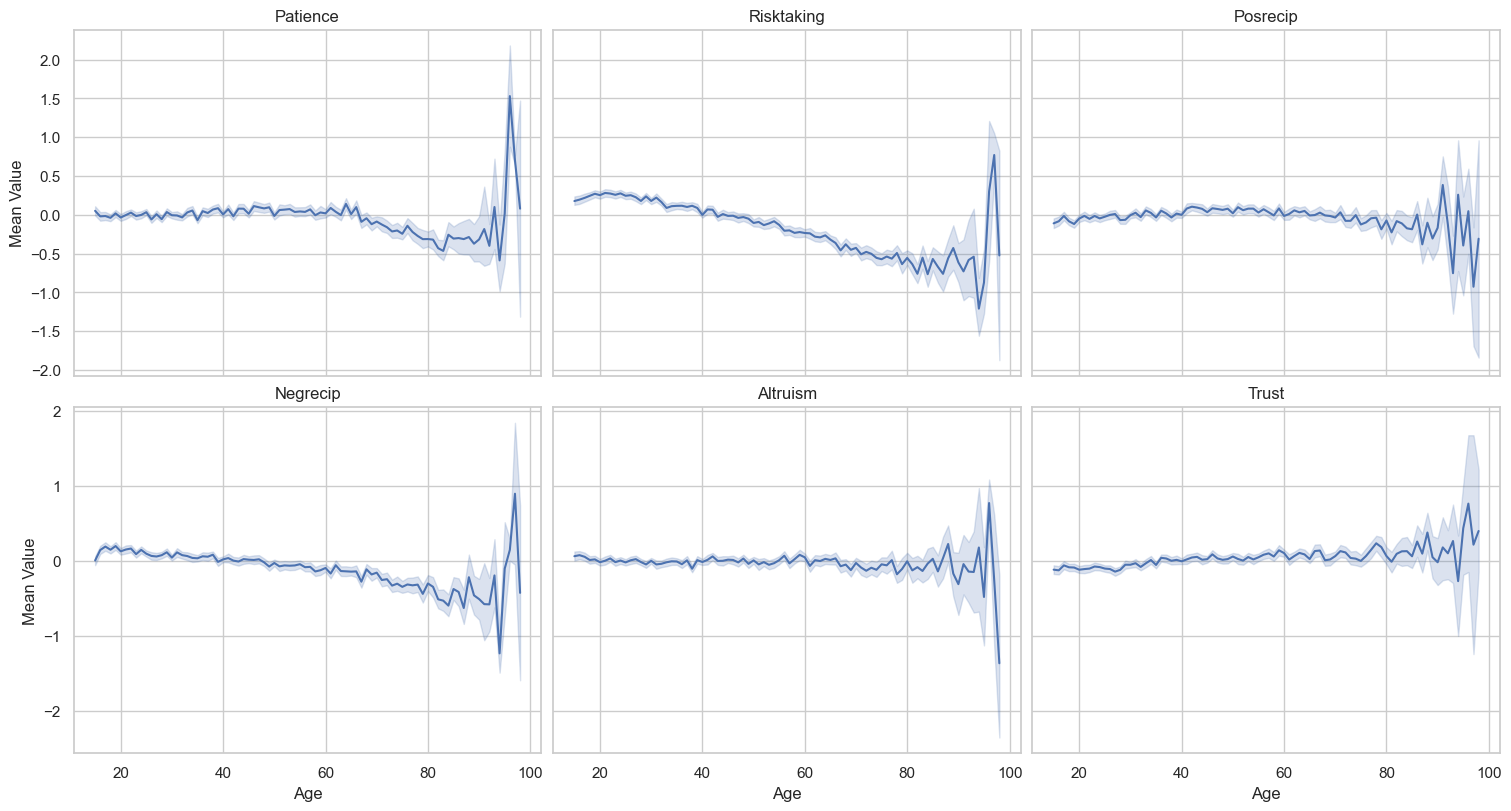

In [15]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, sharex='col', sharey='row', figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

for i, pref in enumerate(prefs):
    sns.lineplot(data=df, x="age", y=pref, ax=axes[i])
    axes[i].set_title(pref.capitalize())
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Mean Value")
    
plt.show()

There are distinct age-related patterns across preferences:
- Risk-taking decreases steadily with age, showing the strongest downward slope among all variables.
- Negative reciprocity also decreases gradually, suggesting older individuals are less likely to retaliate negatively.
- Patience, trust, and positive reciprocity remain relatively stable during early adulthood. While patient and positive reciprocity show decline, trust increases slightly in later years. 
- Altruism appears relatively stable across age groups.

Note that the sharp fluctuations at extreme ages (90+) likely reflect sparse data.


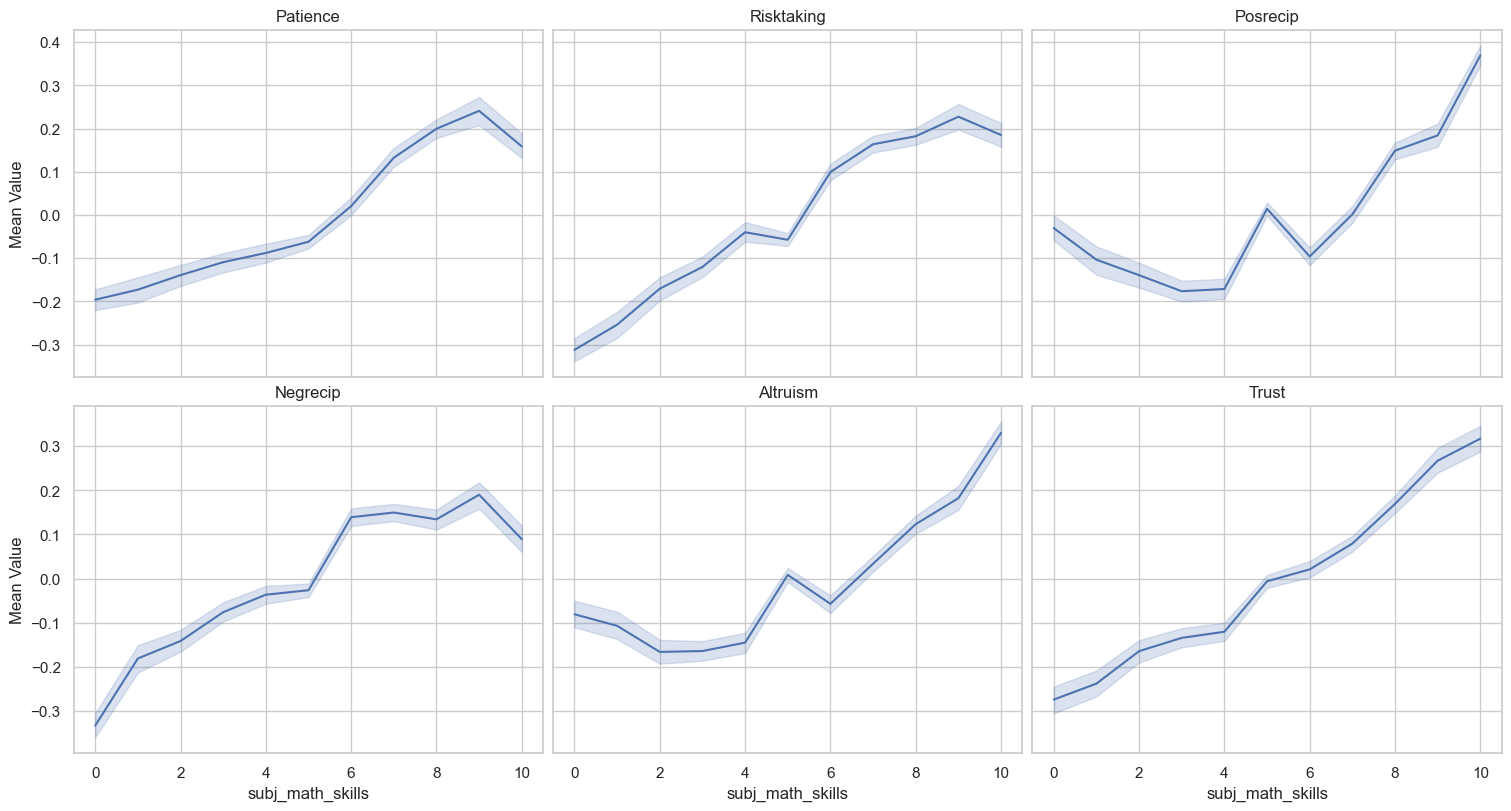

In [16]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, sharex='col', sharey='row', figsize=(15, 8), constrained_layout=True)
axes = axes.flatten()

for i, pref in enumerate(prefs):
    sns.lineplot(data=df, x="subj_math_skills", y=pref, ax=axes[i])
    axes[i].set_title(pref.capitalize())
    axes[i].set_xlabel("subj_math_skills")
    axes[i].set_ylabel("Mean Value")
    
plt.show()

Generally, there are positive correlations across all preferences and subjective math skills. All preferences tend to rise steadily with increasing math skills.

C:\Users\HP\AppData\Local\Temp\ipykernel_22940\238163673.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_stats = df.groupby(['country','continent','isocode']).apply(


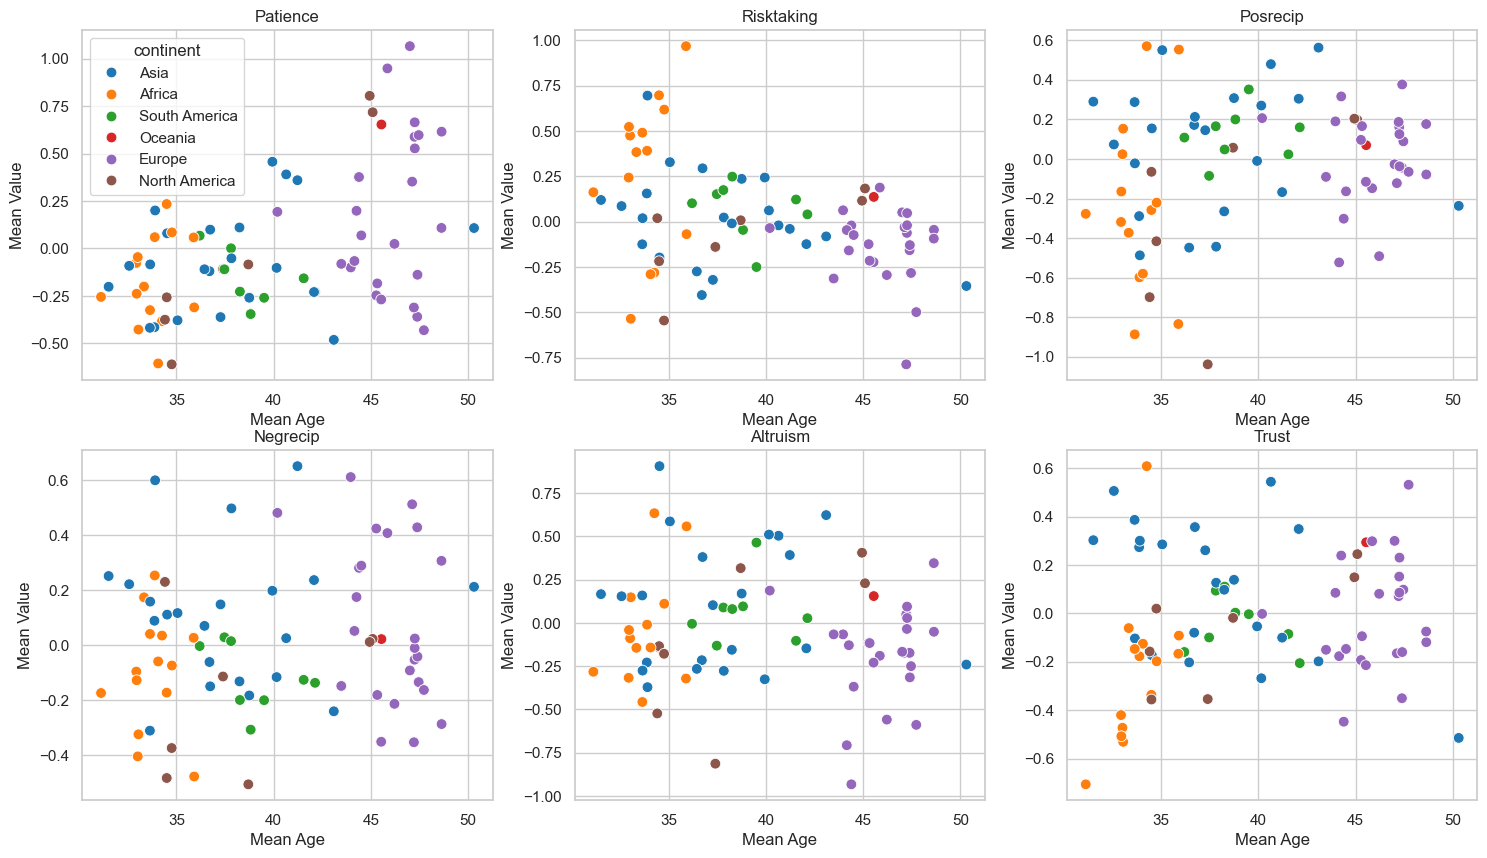

In [17]:
# Add continent column based on isocode
def iso3_to_continent(iso3):
    iso2 = pc.country_alpha3_to_country_alpha2(iso3)
    cont_code = pc.country_alpha2_to_continent_code(iso2)
    return pc.convert_continent_code_to_continent_name(cont_code)
df["continent"] = df["isocode"].apply(iso3_to_continent)

# To calculate weighted means
def weighted_mean(series, weights):
    return (series * weights).sum() / weights.sum()

# Create a dataframe mean for each attribute for each country
country_stats = df.groupby(['country','continent','isocode']).apply(
    lambda g: pd.Series({
        'mean_age': weighted_mean(g['age'], g['wgt']),
        **{f"mean_{pref}": weighted_mean(g[pref], g['wgt']) for pref in prefs}
    }))


sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pref in enumerate(prefs):
    sns.scatterplot(data=country_stats, x='mean_age', y=f"mean_{pref}", hue='continent', ax=axes[i], palette='tab10', s=60, legend=False if i > 0 else 'brief')
    axes[i].set_title(pref.capitalize())
    axes[i].set_xlabel("Mean Age")
    axes[i].set_ylabel("Mean Value")

plt.show()

Next, we explore the relationship between a country’s median age and its average economic and social preference values. Preferences were aggregated at the country level using weighted means to account for sampling weights, ensuring each observation contributed proportionally to the national estimate. 
We found that patience has slight positive relationship with median age. Older populations (Europe, Oceania) tend to report higher patience, and vice versa. Risk-taking shows clear negative relationship, with younger countries, particularly Africa, score higher in risk-taking, while older populations report lower values. Trust manifests higher values in older population, Asia shows greater variability while Europe cluster more tightly.


Overall, demographics, particularly age structure, appear most strongly related to risk-taking, with weaker but noticeable links to patience and trust. However, substantial variation within continents indicates that cultural, historical, and institutional contexts also play a major role in shaping national preference patterns.

Previously, the preference means were calculated with weighted average for each country (country_stats). Using the same logic, I calculated for each year separately. To create an interactive map with "folium", we need to look up the center coordinates for each country based on its isocode. To do so, I used external data to get center coordinates, data source can be found here: https://cdn.jsdelivr.net/gh/gavinr/world-countries-centroids@v1.0.0/dist/countries.csv

We then examine the external data source then join the to tables. For this task, we pick the risk tasking measure to visualize.

In [18]:
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%y", errors="coerce")
df["year"] = df["date"].dt.year


country_stats = df.groupby(['country','continent','isocode','year']).apply(
    lambda g: pd.Series({
        'mean_age': weighted_mean(g['age'], g['wgt']),
        **{f"mean_{pref}": weighted_mean(g[pref], g['wgt']) for pref in prefs}
    }))

country_stats = country_stats.reset_index()

C:\Users\HP\AppData\Local\Temp\ipykernel_22940\3962030670.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_stats = df.groupby(['country','continent','isocode','year']).apply(


In [19]:

cor = pd.read_csv("countries.csv", sep=",")  # This data has duplicated ISO codes because of territories, we want to focus only on mainland territories.
mask = ((~cor["ISO"].duplicated(keep=False))|((cor["ISO"] == "ES") & (cor["COUNTRY"] == "Spain"))) #delete all duplicated territories isocode except for ES-SPAIN
cor_cleaned = cor[mask].copy()
cor_cleaned = cor_cleaned[["ISO", "longitude", "latitude"]]

#The iso code doesn't match with our isocode from the df, we create a mapping ISO-3 -> ISO-2
iso3_to_iso2 = {c.alpha_3: c.alpha_2 for c in pycountry.countries}
country_stats["iso2"] = country_stats["isocode"].map(iso3_to_iso2)

country_stats_coor = pd.merge(country_stats, cor_cleaned.rename(columns={"ISO": "iso2"}), on=["iso2"], how="left")
country_stats_coor


,country,continent,isocode,year,mean_age,mean_patience,mean_risktaking,mean_posrecip,mean_negrecip,mean_altruism,mean_trust,iso2,longitude,latitude
0,Afghanistan,Asia,AFG,2012,31.515291,-0.201779,0.119992,0.289641,0.251384,0.166455,0.302211,AF,66.592161,34.134026
1,Algeria,Africa,DZA,2012,33.886528,0.059459,0.391530,-0.598255,0.253494,-0.009968,-0.177269,DZ,2.655846,28.350970
2,Argentina,South America,ARG,2012,42.131348,-0.229739,0.040558,0.159679,-0.137052,0.027355,-0.205604,AR,-64.532385,-35.697271
3,Australia,Oceania,AUS,2012,45.544940,0.653118,0.136949,0.069660,0.022019,0.155240,0.293594,AU,134.022772,-25.697338
4,Austria,Europe,AUT,2012,47.248957,0.588378,-0.061704,0.161176,-0.052827,-0.034664,0.151921,AT,13.797778,47.631858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,United Kingdom,Europe,GBR,2012,47.261191,0.527191,0.047494,-0.037478,0.024089,0.028477,0.230276,GB,-2.852944,53.978447
74,United States,North America,USA,2012,44.941278,0.804339,0.115982,0.203650,0.011506,0.405797,0.148913,US,-96.331617,38.820809
75,Venezuela,South America,VEN,2012,38.267112,-0.227460,0.248790,0.047843,-0.199534,0.080238,0.110572,VE,-66.364921,7.148325
76,Vietnam,Asia,VNM,2012,38.245951,0.110351,-0.009223,-0.265057,-0.131936,-0.155150,0.097599,VN,105.913388,16.517347


In [20]:
country_stats_coor_2012 = country_stats_coor.query("year == 2012")
world_map_2012 = folium.Map(location = [0,0], zoom_start=2.3)

for country, lat, lon, risktaking in zip(country_stats_coor_2012.country, country_stats_coor_2012.latitude, country_stats_coor_2012.longitude, country_stats_coor_2012.mean_risktaking):
    popup = folium.Popup(f"{country} <br> Mean of risk taking in 2012: <br>{risktaking}", max_width=300)
    folium.Marker([lat, lon], popup=popup).add_to(world_map_2012) 

world_map_2012

In [21]:
country_stats_coor_2013 = country_stats_coor.query("year == 2013")
world_map_2013 = folium.Map(location = [0,0], zoom_start=2.3)

for country, lat, lon, risktaking in zip(country_stats_coor_2013.country, country_stats_coor_2013.latitude, country_stats_coor_2013.longitude, country_stats_coor_2013.mean_risktaking):
    popup = folium.Popup(f"{country} <br> Mean of risk taking in 2013: <br>{risktaking}", max_width=300)
    folium.Marker([lat, lon], popup=popup).add_to(world_map_2013) 

world_map_2013

## Problem 3 - Supervised Machine Learning
#### a)
Predict the subjects' countries of origin based on preference measures using supervised ML techniques. <br>

As we are dealing with categorical outcomes (countries), we'll explore different models for Naive Bayes, and Decision Trees.

In [337]:
import sklearn
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB

# prepare data
# X = df[["patience", "risktaking", "posrecip", "negrecip", "altruism", "trust"]]
X = df[["patience", "risktaking", "posrecip", "negrecip", "altruism", "trust", "subj_math_skills", "female", "age"]]
y = df["country"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)


We  take a look at the Naive Bayes model first, under the assumption of normal distribution of the features.

In [334]:
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)
prediction_NB = model_NB.predict(X_test)
conf_mat_NB = confusion_matrix(y_true=y_test, y_pred=prediction_NB)
print(conf_mat_NB)
print("Accuracy:", accuracy_score(y_test, prediction_NB))
print(classification_report(y_test, y_pred=prediction_NB, zero_division=0))

[[ 6  0  0 ...  0  0  4]
 [ 2  0  0 ...  0  2 10]
 [ 0  1  2 ...  0  1  6]
 ...
 [ 3  1  3 ...  2  0  5]
 [ 0  0  0 ...  2  4  4]
 [ 0  1  0 ...  0  0 22]]
Accuracy: 0.09051049170059505
                      precision    recall  f1-score   support

         Afghanistan       0.06      0.03      0.04       195
             Algeria       0.00      0.00      0.00       218
           Argentina       0.06      0.01      0.02       190
           Australia       0.12      0.13      0.13       203
             Austria       0.18      0.01      0.03       216
          Bangladesh       0.28      0.07      0.11       211
             Bolivia       0.00      0.00      0.00       210
  Bosnia Herzegovina       0.00      0.00      0.00       213
            Botswana       0.11      0.07      0.09       202
              Brazil       0.05      0.02      0.03       191
            Cambodia       0.08      0.08      0.08       188
            Cameroon       0.10      0.29      0.15       214
       

With a total of 76 countries, the probability of guess the correct country randomly would be 1.3%. The 9% accuracy means Naive Bayes is better than random guessing, but still not good for practical use. Although the shapes of features distribution are not perfectly normal, GaussianNB can still work as an approximation. However, we also want to compare the performance of the model under different assumptions.

In [331]:
# transform feature values so the minimum becomes 0, this is due to MultinomialNB() and others don't work with negative values.
X_train_nonneg = X_train.copy()
X_test_nonneg = X_test.copy()

for col in X_train_nonneg.columns:
    min_val = min(X_train_nonneg[col].min(), X_test_nonneg[col].min())
    if min_val < 0:
        shift_val = abs(min_val)
        X_train_nonneg[col] = X_train_nonneg[col] + shift_val
        X_test_nonneg[col] = X_test_nonneg[col] + shift_val
        
models = [GaussianNB(), MultinomialNB(), BernoulliNB(), CategoricalNB()]
for model in models:
    model_NB = model
    model_NB.fit(X_train_nonneg, y_train)
    prediction_NB = model_NB.predict(X_test_nonneg)
    conf_mat_NB = confusion_matrix(y_true=y_test, y_pred=prediction_NB)
    print(str(model))
    print("Accuracy:", sum(conf_mat_NB.diagonal()) / len(prediction_NB))

GaussianNB()
Accuracy: 0.09051049170059505
MultinomialNB()
Accuracy: 0.05424365800187911
BernoulliNB()
Accuracy: 0.03701847792045099
CategoricalNB()
Accuracy: 0.09514563106796116


Among the four Naive Bayes variants tested, GaussianNB and CategoricalNB yield the highest accuracy (~9%), with CategoricalNB being slightly better, but still far from a useful predictive model. 

Next, we want to see how moving to Decision Tree can improve accuracy.

In [321]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=1234)
model_tree.fit(X_train, y_train)
prediction_tree = model_tree.predict(X_test)
conf_mat_tree = confusion_matrix(y_true=y_test, y_pred=prediction_tree)
print("Tree depth:", model_tree.get_depth())
print(conf_mat_tree)
print("Accuracy:", sum(conf_mat_tree.diagonal()) / len(prediction_tree))

Tree depth: 40
[[16  4  4 ...  3  2  2]
 [ 1 30  2 ...  4  5  2]
 [ 0  3  3 ...  2  1  3]
 ...
 [ 3  2  6 ... 18  2  3]
 [ 1  4  7 ...  5 31  0]
 [ 5  5  2 ...  4  3 24]]
Accuracy: 0.07171938615721891


Using a Decision Tree classifier with default settings resulted in an accuracy of approximately 7.1%, lower than Naive Bayes models. The large depth (40) suggests potential overfitting, where the failed to capture general patterns. This indicates that without tuning, Decision Trees are not effective for this dataset.

We want to see how depth can affect the performance.

In [324]:
import statistics
depth_lim = 50
iterations = 20
out_tree = pd.DataFrame(np.zeros([depth_lim*iterations, 3]))
out_tree.columns = ["max depth", "actual depth", "accuracy"]
for depth in range(1, depth_lim+1):
    if depth % 5 == 1:
        print("depth =", depth)
    for i in range(iterations):
        model_tree = DecisionTreeClassifier(max_depth=depth, random_state=i*123)
        model_tree.fit(X_train, y_train)
        prediction_tree = model_tree.predict(X_test)
        out_tree.iloc[(depth-1)*iterations + i] = [depth,
                                                   model_tree.get_depth(), 
                                                   sum(prediction_tree==y_test)/len(prediction_tree)]

depth = 1
depth = 6
depth = 11
depth = 16
depth = 21
depth = 26
depth = 31
depth = 36
depth = 41
depth = 46


<Axes: xlabel='max depth', ylabel='accuracy'>

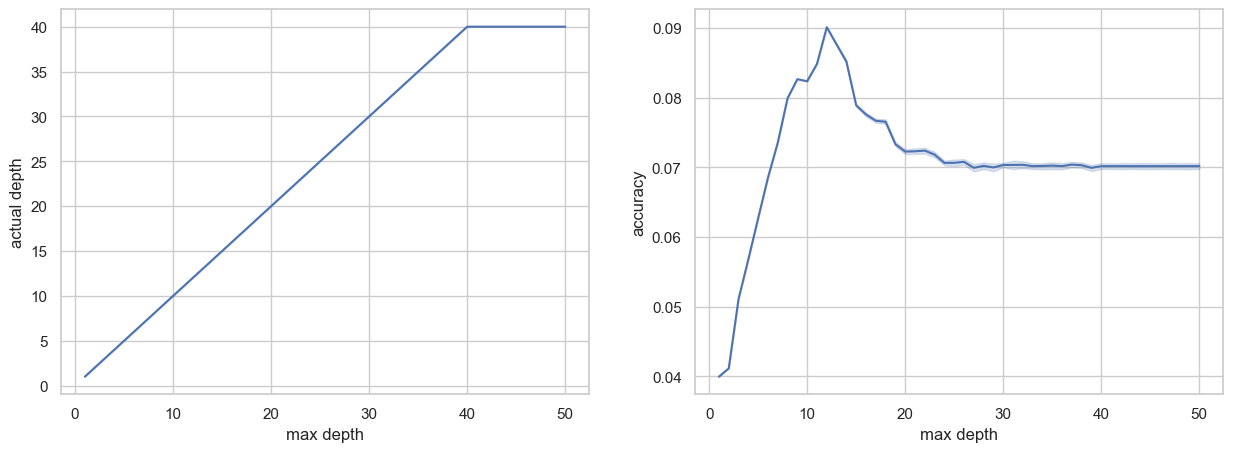

In [325]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(ax=axes[0], data=out_tree, x="max depth", y="actual depth")
sns.lineplot(ax=axes[1], data=out_tree, x="max depth", y="accuracy")

Around the depth of 12, decision tree captures the general patterns the best, but still is inferior to Naive Bayes under CategoricalNB().

In [332]:
from sklearn.neighbors import KNeighborsClassifier
model_KNN = KNeighborsClassifier()
model_KNN.fit(X_train, y_train)
prediction_KNN = model_KNN.predict(X_test)
conf_mat_KNN = confusion_matrix(y_true=y_test, y_pred=prediction_KNN)
print(conf_mat_KNN)
print("Accuracy:", sum(conf_mat_KNN.diagonal()) / len(prediction_KNN))

[[34  9  4 ...  1  0  3]
 [12 34  7 ...  0  1  2]
 [ 5  2 17 ...  0  1  0]
 ...
 [ 8 11 17 ...  3  1  0]
 [ 3  9  5 ...  2  5  1]
 [12 14  9 ...  0  1  7]]
Accuracy: 0.0526777325399311


Similarly, there is not much improvement moving to K-NN algorithm, we could only achive 5% accuracy.

Now we want to test how differet combinations of variable predictors have an effect on performance.

In [346]:
# for linear regression
from itertools import combinations

all_features = ["patience", "risktaking", "posrecip", "negrecip", "altruism", "trust", "subj_math_skills", "female", "age"]
results = []

for k in range (2, len(all_features)+1):
    for subset in combinations(all_features, k):
        X = df[list(subset)]
        y = df["country"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
        model = GaussianNB()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((subset, acc))

best_subset, best_acc = max(results, key=lambda x: x[1])
print("Best subset:", best_subset)
print("Best accuracy:", round(best_acc, 4))

Best subset: ('patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust', 'subj_math_skills', 'female', 'age')
Best accuracy: 0.0905


In [347]:
# for decision tree with depth of 12

all_features = ["patience", "risktaking", "posrecip", "negrecip", "altruism", "trust", "subj_math_skills", "female", "age"]
results = []

for k in range (2, len(all_features)+1):
    for subset in combinations(all_features, k):
        X = df[list(subset)]
        y = df["country"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
        model_tree = DecisionTreeClassifier(max_depth=12)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((subset, acc))

best_subset, best_acc = max(results, key=lambda x: x[1])
print("Best subset:", best_subset)
print("Best accuracy:", round(best_acc, 4))

Best subset: ('patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust', 'subj_math_skills', 'female', 'age')
Best accuracy: 0.0905


In [353]:
# for KNN

all_features = ["patience", "risktaking", "posrecip", "negrecip", "altruism", "trust", "subj_math_skills", "female", "age"]
results = []

for k in range (2, len(all_features)+1):
    for subset in combinations(all_features, k):
        X = df[list(subset)]
        y = df["country"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
        model_KNN = KNeighborsClassifier()
        model_KNN.fit(X_train, y_train)
        y_pred = model_KNN.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((subset, acc))
        
best_subset, best_acc = max(results, key=lambda x: x[1])
print("Best subset:", best_subset)
print("Best accuracy:", round(best_acc, 4))

Best subset: ('altruism', 'female')
Best accuracy: 0.1174


Overall, the models are struggling predicting the correct countries based on prefereces. This suggests that country of origin is not strongly predictable from these variables alone.
For linear regression and decision tree, the models did not benefit much from feature selection. Using all variables yields the best result, but accuracy is still low due to weak relationship. Interestingly, KNN performed better than the other two with only two variables altruism and female. This suggests that extra variables might add noise instead of improving predictions for KNN.

#### b)
Try to fill the gaps in the preference measures in the data using appropriate prediction models.

We use cross-validation to compare different models based on RMSE. In this case, we set up y as patience. with other preference measures being predictive variables.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


target = "patience"          
numeric_cols = ["ison", "wgt", "risktaking", "posrecip", "negrecip", "altruism", "trust", "subj_math_skills", "female", "age"]
cat_cols = ["country"]

# drop irrelevant columns
drop_cols = ["id", "date", "id", "date", "isocode", "region", "language"]
df_cv = df.drop(columns=drop_cols).copy()

feature_cols = [c for c in numeric_cols + cat_cols if c in df_cv.columns and c != target]
X_raw = pd.get_dummies(df_cv[feature_cols], dummy_na=False) # change the country column into binary columns
y = df_cv[target].astype(float)


X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=123)

#standardize selected numeric columns so that numeric feature contributes equally to the distance when apply KNN
#m, s = X_train.mean(), X_train.std(ddof=0).replace(0, 1.0)
#Xtr = (X_train - m) / s
#Xte = (X_test  - m) / s
        

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(max_depth=20, random_state=123),
    "KNN": KNeighborsRegressor()
}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(name, "RMSE:", rmse)


LinearRegression RMSE: 0.9045809624456039
RandomForest RMSE: 0.9022101824963679
KNN RMSE: 0.9744794479398448


RandomForest had the lowest RMSE, very slightly better than LinearRegression. However, LinearRegression will be used in this case because of its simplicity and explainability.

In [37]:
#load and process the original data
df_process = pd.read_csv("individual_new.csv", sep=",")
df_process = df_process.copy()

df_process['age'] = df_process['age'].replace('99 99+', '99')
df_process['age'] = pd.to_numeric(df_process['age'], errors='coerce')
df_process['age'] = df_process['age'].fillna(df_process['age'].median())

cols = ["country", "patience","trust","altruism","posrecip", "negrecip","risktaking","subj_math_skills", "female", "age"]
log = []

for pref in prefs:
    target = pref
    feature_cols = [c for c in cols if c in df_process.columns and c != target]
    X_all = pd.get_dummies(df_process[feature_cols], dummy_na=False)

    for col in X_all.columns:
        if X_all[col].isna().any():
            X_all[col] = X_all[col].fillna(X_all[col].median())
       
    mask_obs = df_process[target].notna()
    mask_mis = ~mask_obs
    
    #training linear regression
    X_obs = X_all.loc[mask_obs]
    y_obs = df_process.loc[mask_obs, target].astype(float)
    lr = LinearRegression()
    lr.fit(X_obs, y_obs)
    #predicting
    X_mis = X_all.loc[mask_mis]
    y_pred = lr.predict(X_mis)
    #filling back
    df_process.loc[mask_mis, target] = y_pred
    log.append((target, int(mask_mis.sum()), "imputed with LinearRegression"))

print("Imputation summary:")
for entry in log:
    print(entry)

df_process.info()
#out_path = "individual_imputed_lr_simple.csv"
#df_process.to_csv(out_path, index=False)
    

Imputation summary:
('patience', 607, 'imputed with LinearRegression')
('risktaking', 634, 'imputed with LinearRegression')
('posrecip', 148, 'imputed with LinearRegression')
('negrecip', 1801, 'imputed with LinearRegression')
('altruism', 434, 'imputed with LinearRegression')
('trust', 1563, 'imputed with LinearRegression')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80337 entries, 0 to 80336
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           80337 non-null  object 
 1   isocode           80337 non-null  object 
 2   ison              80337 non-null  int64  
 3   region            79329 non-null  object 
 4   language          80337 non-null  object 
 5   date              79822 non-null  object 
 6   id                80337 non-null  float64
 7   wgt               80337 non-null  float64
 8   patience          80337 non-null  float64
 9   risktaking        80337 non-null  float64


## Problem 4 - Unsupervised Machine Learning
#### a)
Use the preference measures to cluster *individuals*. <br>
Here I want to know what the optimal number of clusters is. <br>

Select Preference Variables for Clustering（drop rows with missing preference values）

In [284]:
from sklearn.preprocessing import StandardScaler
prefs = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust']
X = df[prefs].dropna()  

Apply K-Means Clustering

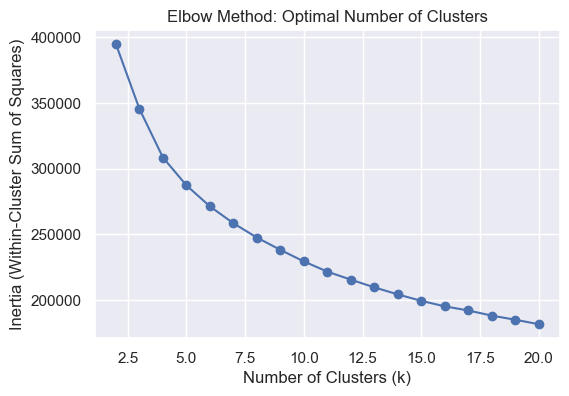

In [57]:
from sklearn.cluster import KMeans
%matplotlib inline
import matplotlib.pyplot as plt
prefs = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust']
X = df[prefs].dropna()
inertia = []
K_range = range(2, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method: Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

Optimal k and Fit Final Model:

I choose k = 6 based on the elbow method, which helps identify the optimal number of clusters by looking at how the within-cluster sum of squares (inertia) decreases as k increases.

Brief Explanation: Why k = 6?
	•	The elbow method curve shows a sharp drop in inertia from k = 2 to k = 5, meaning clustering quality improves a lot.
	•	After k = 6, the inertia still decreases, but much more slowly—indicating diminishing returns from adding more clusters.
	•	This point (k ≈ 6) is the “elbow”, where the benefit of adding more clusters flattens out.
	•	Choosing k = 6 gives a good balance between simplicity and accuracy:
Not too few clusters (underfitting), not too many (overfitting or hard to interpret).

In [63]:
kmeans = KMeans(n_clusters=6, n_init=10, random_state=42)
X['cluster'] = kmeans.fit_predict(X[prefs])
centers = pd.DataFrame(kmeans.cluster_centers_, columns=prefs)
centers['cluster'] = centers.index
print(centers)

   patience  risktaking  posrecip  negrecip  altruism     trust  cluster
0 -0.301019    0.153210 -1.522625  0.058528 -0.760371 -0.347427        0
1 -0.285899    0.304127  0.453178 -0.178365  0.428453 -1.168981        1
2 -0.558382   -0.854883 -0.070721 -0.446145 -0.979056 -0.252752        2
3 -0.214720    0.547641  0.322606  1.003978  0.326252  0.582350        3
4  1.823431    0.248739  0.158507  0.128031  0.131749  0.156322        4
5 -0.448650   -0.511702  0.577462 -0.826071  0.758302  0.724358        5


In [67]:
def describe_cluster(row):
    desc = []
# trust
    if row['trust'] > 0.5:
        desc.append("high trust")
    elif row['trust'] < -0.5:
        desc.append("low trust")
# altruism
    if row['altruism'] > 0.5:
        desc.append("strongly altruistic")
    elif row['altruism'] < -0.5:
        desc.append("self-oriented")
# risktaking
    if row['risktaking'] > 0.5:
        desc.append("risk-taking")
    elif row['risktaking'] < -0.5:
        desc.append("risk-averse")
# posrecip
    if row['posrecip'] > 0.5:
        desc.append("high positive reciprocity")
    elif row['posrecip'] < -0.5:
        desc.append("low positive reciprocity")
    # negrecip
    if row['negrecip'] > 0.5:
        desc.append("high negative reciprocity")
    elif row['negrecip'] < -0.5:
        desc.append("low negative reciprocity")
# patience
    if row['patience'] > 0.5:
        desc.append("patient")
    elif row['patience'] < -0.5:
        desc.append("impulsive")
    return ', '.join(desc)
centers['description'] = centers.apply(describe_cluster, axis=1)
print(centers[['cluster', 'description']])

   cluster                                        description
0        0            self-oriented, low positive reciprocity
1        1                                          low trust
2        2              self-oriented, risk-averse, impulsive
3        3  high trust, risk-taking, high negative recipro...
4        4                                            patient
5        5  high trust, strongly altruistic, risk-averse, ...


Analyze the Clusters & Behavioral Interpretation

Cluster 0 — Self-Protective and Low Reciprocity

This group scores low on altruism and positive reciprocity, indicating a strong tendency to act in self-interest rather than engage in mutual cooperation. They do not strongly reject unfair treatment (neutral on negative reciprocity), and their trust and risk-taking levels are moderate. Overall, these individuals appear cautious in social exchanges and are unlikely to initiate or expect cooperative behavior.

Cluster 1 — Low Trust, Emotionally Reserved

The defining trait of this group is their very low trust in others. They are somewhat altruistic but not strongly so, and they display average levels of patience, reciprocity, and risk-taking. This suggests a reserved or guarded interpersonal style, where people might behave fairly but expect little fairness from others.

Cluster 2 — Self-Oriented, Risk-Averse, and Impulsive

Individuals in this cluster are risk-averse and show low altruism, suggesting self-protective behavior. They are also impatient and show little tendency to reciprocate (especially negatively), indicating an impulsive decision-making style. Overall, this group is characterized by a strong inward focus and a low tolerance for uncertainty.

Cluster 3 — Trusting and Bold, with Strong Reactions to Unfairness

This group is defined by high trust and risk-taking, paired with high negative reciprocity. These individuals believe in others but react strongly when treated unfairly. They are moderately altruistic and patient. This profile reflects people who are socially open and bold but have a strong sense of justice and are quick to retaliate when wronged.

Cluster 4 — Patient and Balanced

The standout trait of this group is patience. On other dimensions—trust, altruism, risk-taking, and reciprocity—they are largely moderate. These individuals likely have a calm, composed approach to decision-making and interpersonal interactions. They are steady and less emotionally reactive compared to other groups.

Cluster 5 — Cooperative and Cautious Idealists

This group combines high trust, strong altruism, and risk aversion. They are also patient and show low tendencies for negative reciprocity, meaning they avoid revenge or retaliation. These individuals tend to believe in others, behave generously, and prefer to avoid conflict. They embody a pro-social, harmonious behavioral style.

#### b)
Similarly, use the preference measures to cluster *countries*. <br>
I want to find out the optimal number of clusters. <br>

Aggregate to Country-Level and compute mean preference scores

In [59]:
prefs = ['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism', 'trust']
country_means = df.groupby('country')[prefs].mean()
country_means

,patience,risktaking,posrecip,negrecip,altruism,trust
country,,,,,,
Afghanistan,-0.207378,0.172178,0.299183,0.328665,0.177953,0.302797
Algeria,0.055622,0.395508,-0.554917,0.213758,0.031802,-0.160674
Argentina,-0.252315,-0.027127,0.192480,-0.226149,0.025220,-0.242005
Australia,0.704652,0.065509,0.073512,-0.002397,0.179588,0.377240
Austria,0.542318,-0.143761,0.205746,-0.119974,0.003779,0.126397
...,...,...,...,...,...,...
United Kingdom,0.540921,-0.006768,-0.050179,-0.005264,0.032747,0.245542
United States,0.858778,0.092867,0.157842,-0.007393,0.382351,0.227917
Venezuela,-0.253318,0.183338,0.017404,-0.234512,0.081929,0.115986


Standardize Features

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_country = scaler.fit_transform(country_means)

Find Optimal Number of Clusters (Elbow Method)

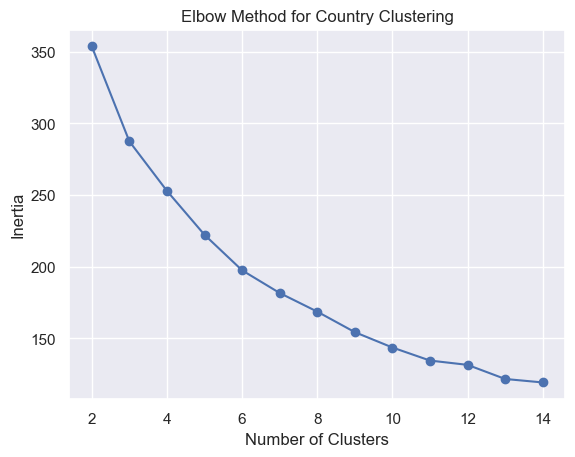

In [61]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 15)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_country)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Country Clustering")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

Run Final K-Means on Country Data

In [62]:
k_opt = 7
kmeans = KMeans(n_clusters=k_opt, n_init=10, random_state=42)
country_means['cluster'] = kmeans.fit_predict(X_country)
# Compute mean profile of each country cluster
cluster_profiles = country_means.groupby('cluster')[prefs].mean()
print(cluster_profiles)

         patience  risktaking  posrecip  negrecip  altruism     trust
cluster                                                              
0        0.030033    0.632028 -0.301609  0.036423 -0.086836 -0.192605
1       -0.246322   -0.169718  0.316044 -0.265652  0.505914 -0.198793
2       -0.168672    0.023105  0.304258  0.031244  0.266184  0.350645
3       -0.165394    0.041366 -0.539910  0.016470 -0.488567 -0.303088
4       -0.225798   -0.200958 -0.011724 -0.215430 -0.138635 -0.012265
5        0.077264   -0.039390 -0.026269  0.404791 -0.066058 -0.114045
6        0.706798   -0.019137  0.096297 -0.017001  0.035993  0.214087


Interpretation：

Cluster 0：Risk-taking, low-trust societies with limited social cooperation.

These countries tend to be adventurous and willing to take risks. They show slightly above-average patience but have relatively low trust in others. Their social orientation is limited, suggesting more self-interested behavior.


Cluster 1：Cautious but generous and fair-minded cultures.

This cluster is characterized by strong altruism and positive reciprocity. People here are cautious, risk-averse, and tend to act with fairness and generosity. However, trust levels remain low, indicating a preference for careful cooperation.

	

Cluster 2：Moderately trusting and socially cooperative communities.

Countries in this cluster are moderately prosocial — they score above average in trust, altruism, and reciprocity. They are neither particularly patient nor impulsive. This reflects balanced, community-oriented societies.

	

Cluster 3：Highly individualistic and distrustful societies.

This group shows extremely low levels of altruism, trust, and positive reciprocity. People are individualistic, less socially motivated, and reluctant to engage in mutual support. These may be highly self-reliant cultures with limited communal bonds.

	

Cluster 4：Pragmatic societies with a short-term, low-trust outlook.

Countries in this cluster tend to be impatient, less trusting, and show low altruism. They don’t strongly lean toward any trait but overall show a short-term, self-focused orientation.

	

Cluster 5：Justice-oriented societies with low interpersonal warmth.

This cluster stands out for its high willingness to punish unfairness (negative reciprocity). People are slightly patient but low in trust and altruism. It reflects cultures that value justice over warmth or generosity.

	

Cluster 6：Future-focused, patient, and moderately trusting cultures.

These countries are highly patient and moderately trusting. They display emotional composure and a future-oriented mindset. Though not extremely prosocial, they appear calm and confident in social interactions.
